
[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB
Rows before cleaning: 16598
Rows after removing duplicates: 16598

Standardised Genre labels:
Genre
Action

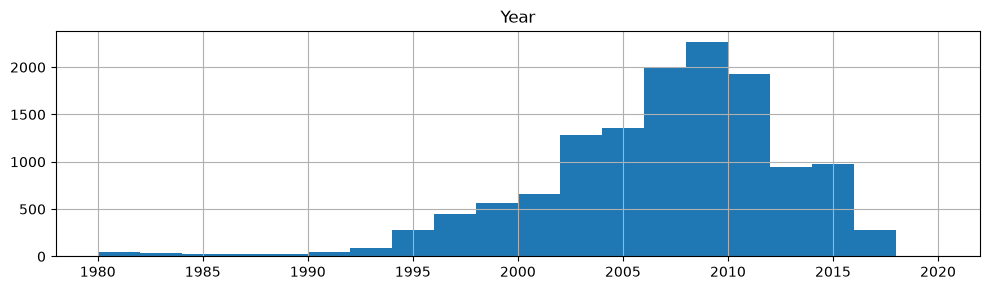

         Year        Publisher release_era  publisher_frequency
14303  2006.0     Myelin Media       2000s                    2
13455  2008.0          Ubisoft       2000s                  718
6724   2015.0             Sega       2010s                  514
898    2003.0  Electronic Arts       2000s                 1079
8484   2010.0      Square Enix       2010s                  187
['Name', 'Platform', 'Year', 'Genre', 'Publisher', 'release_era', 'publisher_frequency']
Columns after encoding: 582
Ranges before scaling:
       Year  publisher_frequency
min  1980.0                    1
max  2020.0                 1079

Training means after scaling:
Year                  -0.0
publisher_frequency    0.0
dtype: float64
Prepared train shape: (13278, 581)
Prepared test shape:  (3320, 581)
Shape: (16598, 11)

Data types:
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales

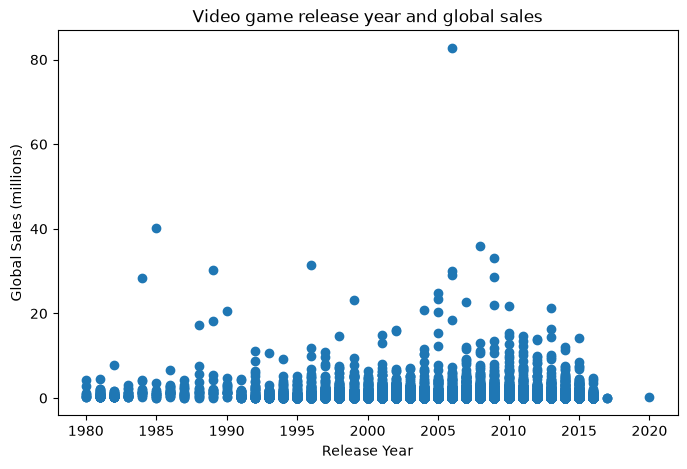

Training observations: 13061
Test observations: 3266
Intercept: 44.75373275657805
Coefficient: -0.022040081706878975
Model equation: Global_Sales = 44.754 + -0.022 × Year
Predicted change for +10 years: -0.220 million units


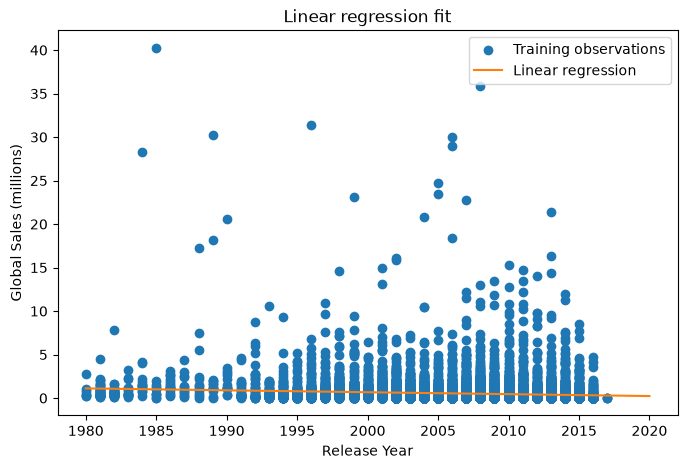

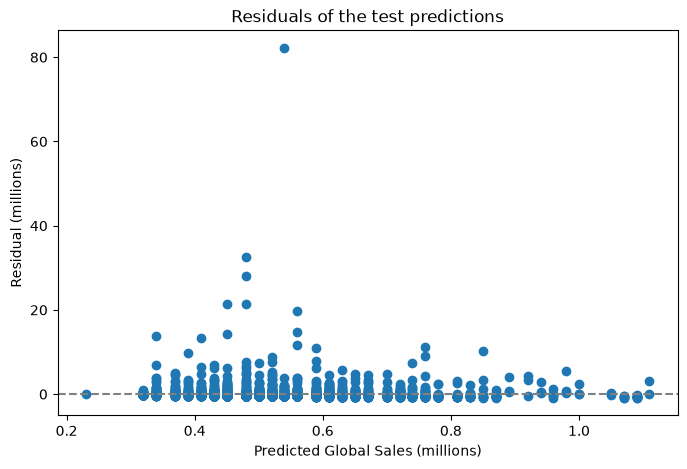

Training sum of squared errors: 25,850.99
                 Training   Test
MAE (millions)      0.577  0.616
MSE (millions²)     1.979  4.272
RMSE (millions)     1.407  2.067
R²                  0.008  0.000
Intercept: 78.851
Correlation between Year and Global Sales: -0.07


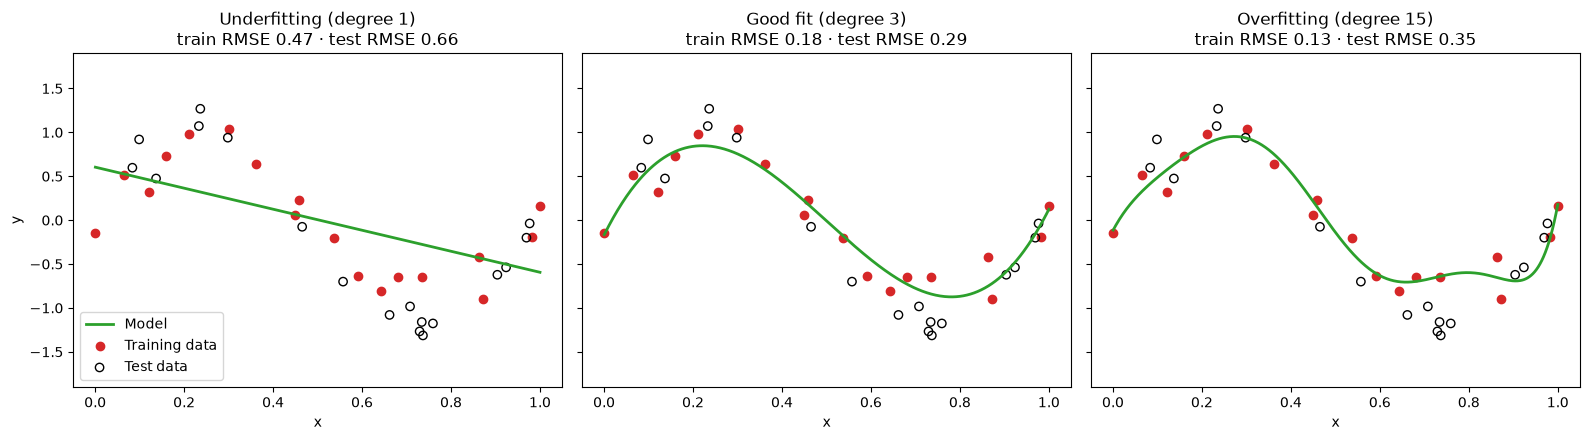

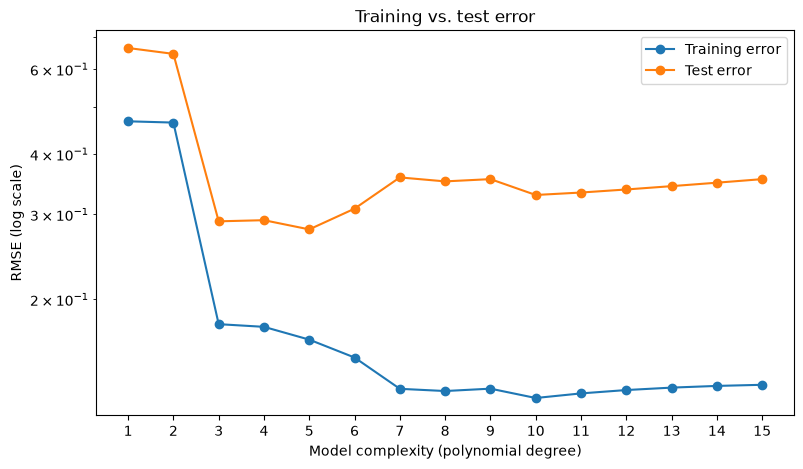

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/Noah/GitHub/video_games_sales.csv")
df.head()
%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

df = pd.read_csv("/Users/Noah/GitHub/video_games_sales.csv")
df.head()
df.shape, df.info()
df.isna().sum(), df.duplicated().sum(), df.describe()
import pandas as pd
import numpy as np

# Make a copy of the original dataset and remove duplicate rows
df_clean = df.copy().drop_duplicates()

# Standardise text/categorical columns
df_clean["Name"] = df_clean["Name"].str.strip()
df_clean["Platform"] = df_clean["Platform"].str.strip().str.upper()
df_clean["Genre"] = df_clean["Genre"].str.strip().str.title()
df_clean["Publisher"] = df_clean["Publisher"].str.strip()

# Replace impossible Year values with missing values
df_clean.loc[df_clean["Year"] < 1950, "Year"] = np.nan
df_clean.loc[df_clean["Year"] > 2026, "Year"] = np.nan

# Sales cannot realistically be negative, so replace negative values with NaN
sales_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

for column in sales_columns:
    df_clean.loc[df_clean[column] < 0, column] = np.nan

# Display cleaning results
print("Rows before cleaning:", len(df))
print("Rows after removing duplicates:", len(df_clean))

print("\nStandardised Genre labels:")
print(df_clean["Genre"].value_counts(dropna=False))

print("\nStandardised Platform labels:")
print(df_clean["Platform"].value_counts(dropna=False))

print("\nMissing values:")
print(df_clean.isna().sum())
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert all(
    genre == genre.strip().title()
    for genre in df_clean["Genre"].dropna()
), "Genre labels not standardised"
assert all(
    platform == platform.strip().upper()
    for platform in df_clean["Platform"].dropna()
), "Platform labels not standardised"
assert df_clean["Year"].dropna().between(1950, 2026).all(), "Impossible years remain"
sales_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

assert (
    df_clean[sales_columns].dropna() >= 0
).all().all(), "Negative sales values remain"

print("Section 2 checks passed:", df_clean.shape)
target = "Global_Sales"
id_cols = ["Rank"]
leaky_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
X = df_clean.drop(columns=[target] + leaky_cols + id_cols)
y = df_clean[target]

print("Features used:", X.columns.tolist())

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("train:", X_train.shape, " test:", X_test.shape)
Xtr, Xte = X_train.copy(), X_test.copy()
print("Missing values before imputation:")
print(Xtr.isna().sum())

year_median = Xtr["Year"].median()

Xtr["Year"] = Xtr["Year"].fillna(year_median)
Xte["Year"] = Xte["Year"].fillna(year_median)

Xtr["Publisher"] = Xtr["Publisher"].fillna("Unknown")
Xte["Publisher"] = Xte["Publisher"].fillna("Unknown")

print("\nMedian Year from training data:", year_median)

print("\nMissing values after imputation - training:")
print(Xtr.isna().sum())

print("\nMissing values after imputation - test:")
print(Xte.isna().sum())
print(Xtr[["Year"]].describe())

print("\nFive most recent years:")
print(Xtr["Year"].nlargest(5))

Xtr[["Year"]].hist(bins=20, figsize=(10, 3))

plt.tight_layout()
plt.show()
## 8. Feature engineering

def add_features(data):
    # Work on a copy so the original dataframe is not modified.
    result = data.copy()

    # Feature 1: Group release years into broader gaming eras.
    result["release_era"] = pd.cut(
        result["Year"],
        bins=[0, 1989, 1999, 2009, 2019, np.inf],
        labels=["Before 1990", "1990s", "2000s", "2010s", "2020s"],
    ).astype("object")

    return result


# Apply the same row-wise feature engineering to train and test data.
Xtr = add_features(Xtr)
Xte = add_features(Xte)


# Feature 2: Number of games associated with each publisher.
# IMPORTANT: learn publisher frequencies from the TRAINING data only.
publisher_frequency = Xtr["Publisher"].value_counts()

Xtr["publisher_frequency"] = (
    Xtr["Publisher"].map(publisher_frequency).fillna(0)
)

Xte["publisher_frequency"] = (
    Xte["Publisher"].map(publisher_frequency).fillna(0)
)


# Look at the new features
print(
    Xtr[
        ["Year", "Publisher", "release_era", "publisher_frequency"]
    ].head()
)

print(Xtr.columns.tolist())
## 9. Encoding categorical variables

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd

# Release era has a meaningful chronological order,
# so it is treated as an ordinal variable.
era_order = ["Before 1990", "1990s", "2000s", "2010s", "2020s"]

era_encoder = OrdinalEncoder(categories=[era_order])

# Fit the encoder on training data only.
Xtr[["release_era"]] = era_encoder.fit_transform(
    Xtr[["release_era"]]
)

# Apply the same encoding to test data.
Xte[["release_era"]] = era_encoder.transform(
    Xte[["release_era"]]
)

# Platform, Genre and Publisher have no meaningful order,
# so they are treated as nominal variables.
nominal_cols = ["Platform", "Genre", "Publisher"]

nominal_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Learn the categories from training data only.
train_nominal = pd.DataFrame(
    nominal_encoder.fit_transform(Xtr[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols),
    index=Xtr.index
)

# Apply the same encoding to test data.
test_nominal = pd.DataFrame(
    nominal_encoder.transform(Xte[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols),
    index=Xte.index
)

# Replace the original categorical columns with the encoded columns.
Xtr = pd.concat(
    [Xtr.drop(columns=nominal_cols), train_nominal],
    axis=1
)

Xte = pd.concat(
    [Xte.drop(columns=nominal_cols), test_nominal],
    axis=1
)

print("Columns after encoding:", Xtr.shape[1])
## 10. Scaling numerical variables

from sklearn.preprocessing import StandardScaler

# One-hot columns are already 0/1, so scale only
# continuous or count-based numerical variables.
numeric_cols = [
    "Year",
    "publisher_frequency"
]

# Look at the ranges before scaling.
print("Ranges before scaling:")
print(Xtr[numeric_cols].agg(["min", "max"]))

# The scaler learns the mean and standard deviation
# from the training data only.
scaler = StandardScaler()

Xtr[numeric_cols] = scaler.fit_transform(
    Xtr[numeric_cols]
)

# The test set uses the SAME values learned from
# the training data.
Xte[numeric_cols] = scaler.transform(
    Xte[numeric_cols]
)

print("\nTraining means after scaling:")
print(Xtr[numeric_cols].mean().round(2))
## 11. Doing the same preparation with a pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np


def row_wise_features(data):
    """Create features using each row only; no dataset-wide values are learned."""
    
    result = data.copy()

    # Create a release era from the game's year.
    result["release_era"] = pd.cut(
        result["Year"],
        bins=[0, 1989, 1999, 2009, 2019, np.inf],
        labels=["Before 1990", "1990s", "2000s", "2010s", "2020s"],
    ).astype("object")

    # Create a numeric feature representing the length of the game's title.
    result["title_length"] = result["Name"].fillna("").str.len()

    # Name itself has too many unique categories, so remove it
    # after extracting title_length.
    return result.drop(columns="Name")


# Assign each column to the preprocessing it needs.

numeric_cols = [
    "Year",
    "title_length"
]

ordinal_cols = [
    "release_era"
]

nominal_cols = [
    "Platform",
    "Genre",
    "Publisher"
]

# Release era has a meaningful chronological order.
era_order = [
    "Before 1990",
    "1990s",
    "2000s",
    "2010s",
    "2020s"
]


# NUMERIC:
# Fill missing values using training medians,
# then standardise the numeric variables.
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])


# ORDINAL:
# Fill missing values and encode release era
# according to its chronological order.
ordinal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(categories=[era_order])),
])


# NOMINAL:
# Label missing categories as Unknown,
# then create 0/1 columns for each category.
nominal_pipeline = Pipeline([
    ("impute", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encode", OneHotEncoder(
        handle_unknown="ignore"
    )),
])


# Send each type of variable through
# its appropriate preprocessing pipeline.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("nom", nominal_pipeline, nominal_cols),
])


# First create the new features,
# then perform the preprocessing.
preprocessing_pipeline = Pipeline([
    ("features", FunctionTransformer(row_wise_features)),
    ("preprocess", preprocessor),
])


# Learn all necessary values from TRAINING data
# and transform the training data.
X_train_prepared = preprocessing_pipeline.fit_transform(
    X_train
)


# Apply those already-learned values to the test data.
X_test_prepared = preprocessing_pipeline.transform(
    X_test
)


print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape: ", X_test_prepared.shape)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
## 3. Load the video game sales dataset

 ##This dataset contains information about video game sales across different
 # platforms, genres, publishers and release years.

#The columns include:

#- `Rank`: sales ranking of the game
#- `Platform`: platform on which the game was released
#- `Name`: name of the video game
#- `Year`: year of release
#- `Genre`: genre of the game
#- `Publisher`: publisher of the game
#- `NA_Sales`: sales in North America
#- `EU_Sales`: sales in Europe
#- `JP_Sales`: sales in Japan
#- `Other_Sales`: sales in other regions
#- `Global_Sales`: worldwide sales — our target

#The aim is to predict `Global_Sales` using information about the video game.
df.head()
print('Shape:', df.shape)

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isna().sum())

df.describe().round(2)
X = df[['Year']]
y = df['Global_Sales']

print('X shape:', X.shape)
print('y shape:', y.shape)
plt.figure(figsize=(8, 5))

plt.scatter(df['Year'], df['Global_Sales'])

plt.xlabel('Release Year')
plt.ylabel('Global Sales (millions)')
plt.title('Video game release year and global sales')

plt.show()
## 7. Train vs. test data

# Remove observations where Year is missing.
valid_rows = X["Year"].notna() & y.notna()

X = X.loc[valid_rows]
y = y.loc[valid_rows]

# Split the data: 80% training and 20% testing.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
model = LinearRegression()

model.fit(X_train, y_train)

print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])
print(
    f'Model equation: Global_Sales = {model.intercept_:.3f} '
    f'+ {model.coef_[0]:.3f} × Year'
)

print(
    f'Predicted change for +10 years: '
    f'{10 * model.coef_[0]:.3f} million units'
)
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Year': X_test['Year'].values,
    'actual_global_sales': y_test.values,
    'predicted_global_sales': y_pred.round(2)
})

results.head(10)
x_line = pd.DataFrame({
    'Year': np.linspace(
        df['Year'].dropna().min(),
        df['Year'].dropna().max(),
        200
    )
})

y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train['Year'],
    y_train,
    label='Training observations'
)

plt.plot(
    x_line['Year'],
    y_line,
    color='C1',
    label='Linear regression'
)

plt.xlabel('Release Year')
plt.ylabel('Global Sales (millions)')
plt.title('Linear regression fit')

plt.legend()
plt.show()
results['residual'] = y_test.values - y_pred
results['residual'] = results['residual'].round(2)

results.head(10)
plt.figure(figsize=(8, 5))

plt.scatter(
    results['predicted_global_sales'],
    results['residual']
)

plt.axhline(0, linestyle='--', color='grey')

plt.xlabel('Predicted Global Sales (millions)')
plt.ylabel('Residual (millions)')
plt.title('Residuals of the test predictions')

plt.show()
train_predictions = model.predict(X_train)

train_residuals = y_train.values - train_predictions

train_sse = np.sum(train_residuals ** 2)

print(f'Training sum of squared errors: {train_sse:,.2f}')
def regression_metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)

    return {
        'MAE (millions)': mean_absolute_error(y_true, y_hat),
        'MSE (millions²)': mse,
        'RMSE (millions)': np.sqrt(mse),
        'R²': r2_score(y_true, y_hat),
    }


metrics_1f = pd.DataFrame({
    'Training': regression_metrics(
        y_train,
        model.predict(X_train)
    ),
    'Test': regression_metrics(
        y_test,
        y_pred
    ),
})

print(metrics_1f.round(3))
features = ['Year', 'Platform', 'Genre', 'Publisher']

X_multi = df[features]

# Convert categorical variables into numeric dummy variables
X_multi = pd.get_dummies(
    X_multi,
    columns=['Platform', 'Genre', 'Publisher'],
    drop_first=True
)

# Remove rows with missing values
valid_rows = X_multi.notna().all(axis=1) & y.notna()

X_multi = X_multi.loc[valid_rows]
y_multi = y.loc[valid_rows]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_m = model_multi.predict(X_test_m)

comparison = pd.DataFrame({
    'Year only (test)': regression_metrics(y_test, y_pred),
    'Multiple features (test)': regression_metrics(y_test_m, y_pred_m),
})

comparison.drop(index='MSE (millions²)').round(3)
learned = pd.Series(
    model_multi.coef_,
    index=X_train_m.columns
)

print("Intercept:", round(model_multi.intercept_, 3))

learned_coefficients = pd.DataFrame({
    'Learned coefficient': learned.round(3)
})

learned_coefficients
print(
    f"Correlation between Year and Global Sales: "
    f"{df['Year'].corr(df['Global_Sales']):.2f}"
)
noise_rng = np.random.default_rng(0)
n_noise = 10

X_noisy = X_multi.copy()
for k in range(n_noise):
    X_noisy[f'noise_{k}'] = noise_rng.normal(size=len(X_noisy))

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42
)
model_noisy = LinearRegression().fit(X_train_n, y_train_n)

pd.DataFrame({
    'Training R²': [model_multi.score(X_train_m, y_train_m), model_noisy.score(X_train_n, y_train_n)],
    'Test R²':     [model_multi.score(X_test_m, y_test_m),   model_noisy.score(X_test_n, y_test_n)],
}, index=['4 real features', f'4 real + {n_noise} noise features']).round(3)
toy_rng = np.random.default_rng(39)
true_curve = lambda x: np.sin(2 * np.pi * x)

x_toy_train = np.sort(
    np.clip(
        np.linspace(0, 1, 18) + toy_rng.normal(0, 0.02, 18),
        0,
        1
    )
)

y_toy_train = (
    true_curve(x_toy_train)
    + toy_rng.normal(0, 0.25, 18)
)

x_toy_test = np.sort(
    toy_rng.uniform(
        x_toy_train.min(),
        x_toy_train.max(),
        18
    )
)

y_toy_test = (
    true_curve(x_toy_test)
    + toy_rng.normal(0, 0.25, 18)
)


def poly_model(degree):
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    ).fit(
        x_toy_train[:, None],
        y_toy_train
    )


def rmse(m, x, y_true):
    return np.sqrt(
        mean_squared_error(
            y_true,
            m.predict(x[:, None])
        )
    )


x_grid = np.linspace(
    x_toy_train.min(),
    x_toy_train.max(),
    500
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
    sharey=True
)

for ax, (degree, label) in zip(
    axes,
    [
        (1, 'Underfitting'),
        (3, 'Good fit'),
        (15, 'Overfitting')
    ]
):
    m = poly_model(degree)

    ax.plot(
        x_grid,
        m.predict(x_grid[:, None]),
        color='C2',
        lw=2,
        label='Model'
    )

    ax.scatter(
        x_toy_train,
        y_toy_train,
        color='C3',
        label='Training data'
    )

    ax.scatter(
        x_toy_test,
        y_toy_test,
        facecolors='none',
        edgecolors='k',
        label='Test data'
    )

    ax.set_ylim(-1.9, 1.9)

    ax.set_title(
        f'{label} (degree {degree})\n'
        f'train RMSE {rmse(m, x_toy_train, y_toy_train):.2f} · '
        f'test RMSE {rmse(m, x_toy_test, y_toy_test):.2f}'
    )

    ax.set_xlabel('x')

axes[0].set_ylabel('y')
axes[0].legend(loc='lower left')

plt.tight_layout()
plt.show()
degrees = range(1, 16)

train_err = [
    rmse(poly_model(d), x_toy_train, y_toy_train)
    for d in degrees
]

test_err = [
    rmse(poly_model(d), x_toy_test, y_toy_test)
    for d in degrees
]

plt.figure(figsize=(9, 5))

plt.plot(
    degrees,
    train_err,
    'o-',
    label='Training error'
)

plt.plot(
    degrees,
    test_err,
    'o-',
    label='Test error'
)

plt.yscale('log')
plt.xticks(list(degrees))

plt.xlabel('Model complexity (polynomial degree)')
plt.ylabel('RMSE (log scale)')
plt.title('Training vs. test error')

plt.legend()
plt.show()